Alphas: [0.3437 0.     0.     0.3437 0.     0.    ]
w: [1.375 1.375]
b: 4.5
Support Vectors: [0 3]


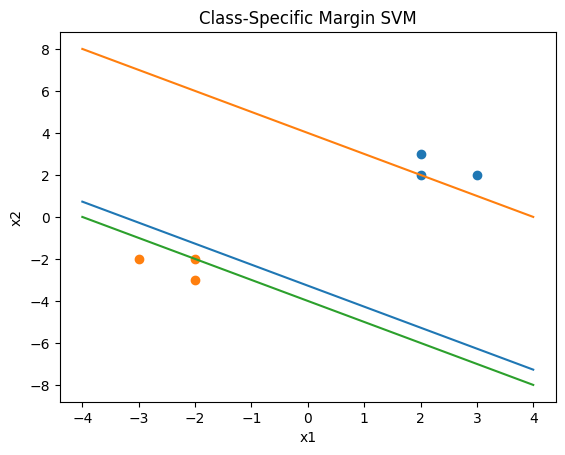

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from cvxopt import matrix, solvers

def svm_class_margin_dual_cvxopt(X, y, C_pos, C_neg, eps=1e-7):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)
    n, d = X.shape

    # Per-sample required margin
    C = np.where(y > 0, C_pos, C_neg)

    # Linear kernel Gram matrix
    K = X @ X.T
    P = (y[:, None] * y[None, :]) * K

    # Convert max problem to min
    P_cvx = matrix(P, tc='d')
    q_cvx = matrix(-C, tc='d')
    G_cvx = matrix(-np.eye(n), tc='d')
    h_cvx = matrix(np.zeros(n), tc='d')
    A_cvx = matrix(y.reshape(1, -1), tc='d')
    b_cvx = matrix(0.0, tc='d')

    solvers.options['show_progress'] = False
    sol = solvers.qp(P_cvx, q_cvx, G_cvx, h_cvx, A_cvx, b_cvx)

    alphas = np.array(sol['x']).reshape(-1)

    # Support vectors
    sv = np.where(alphas > eps)[0]

    # Compute w
    w = (alphas * y) @ X

    # Compute b using SVs
    b_vals = [y[i] * C[i] - np.dot(w, X[i]) for i in sv]
    b = np.mean(b_vals)

    return alphas, w, b, sv


def plot_svm(X, y, w, b, C_pos, C_neg):
    X = np.asarray(X)
    y = np.asarray(y)

    plt.figure()

    # Plot data points
    plt.scatter(X[y==1][:,0], X[y==1][:,1])
    plt.scatter(X[y==-1][:,0], X[y==-1][:,1])

    # Create line grid
    x_vals = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200)

    # Decision boundary: w1*x + w2*y + b = 0
    y_dec = -(w[0]*x_vals + b) / w[1]

    # Positive margin line: w·x + b = C_pos
    y_pos_margin = -(w[0]*x_vals + b - C_pos) / w[1]

    # Negative margin line: w·x + b = -C_neg
    y_neg_margin = -(w[0]*x_vals + b + C_neg) / w[1]

    plt.plot(x_vals, y_dec)
    plt.plot(x_vals, y_pos_margin)
    plt.plot(x_vals, y_neg_margin)

    plt.title("Class-Specific Margin SVM")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()


# ---------------- Example ----------------
if __name__ == "__main__":
    X = np.array([
        [2,2],
        [2,3],
        [3,2],
        [-2,-2],
        [-2,-3],
        [-3,-2]

    ])
    y = np.array([1,1,1,-1,-1,-1])

    C_pos = 10.0
    C_neg = 1.0

    alphas, w, b, sv = svm_class_margin_dual_cvxopt(X, y, C_pos, C_neg)

    print("Alphas:", np.round(alphas, 4))
    print("w:", np.round(w, 4))
    print("b:", np.round(b, 4))
    print("Support Vectors:", sv)

    plot_svm(X, y, w, b, C_pos, C_neg)


Let's generate new data with three features using `make_blobs`.

In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

# Generate custom data points with 3 features
X_3d, y_3d = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.5, n_features=3)

print("Shape of X_3d (samples, features):", X_3d.shape)
print("First 5 rows of X_3d:\n", X_3d[:5])


Shape of X_3d (samples, features): (100, 3)
First 5 rows of X_3d:
 [[  4.77183145  -6.16887781  -8.66706484]
 [  0.90021412  -5.86023057  -7.97565954]
 [  1.88388165 -11.7415282   -8.41669106]
 [  2.43411897  -5.66033401  -5.93566633]
 [ -2.61721281  10.51958548   5.18233287]]


Now, we'll train a Decision Tree Classifier on this 3-feature data. Even though we'll visualize only two features, the model learns from all three.

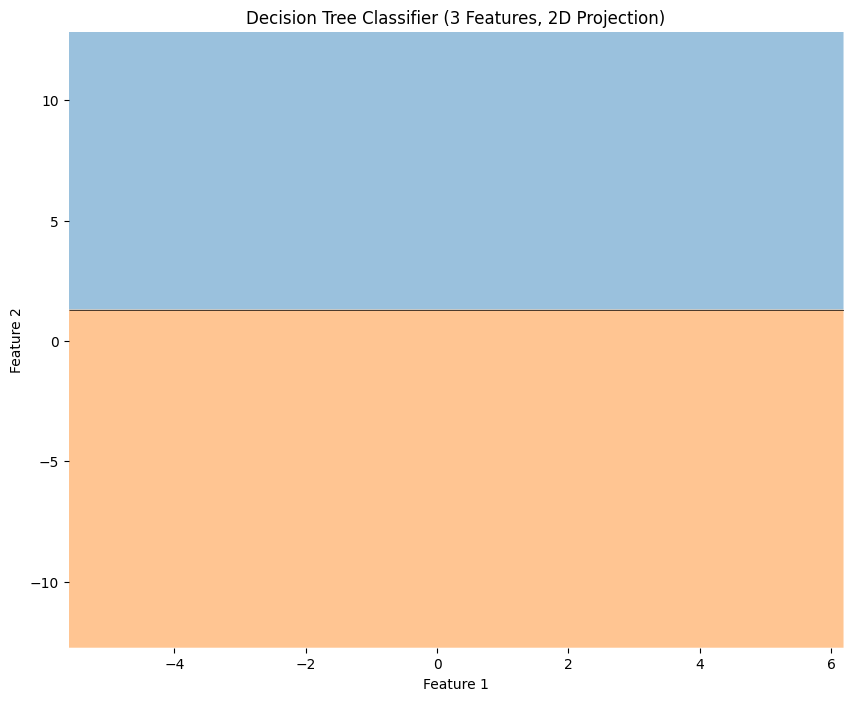

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from mlxtend.plotting import plot_decision_regions

# Train a Decision Tree Classifier on the 3-feature data
dt_classifier_3d = DecisionTreeClassifier(random_state=42, max_depth=3)
dt_classifier_3d.fit(X_3d, y_3d)

# To visualize using plot_decision_regions (which is 2D), we'll use the first two features.
# The model still uses all three features to make its decisions.
plt.figure(figsize=(10, 8))

# Calculate the mean of the third feature to use as a filler value
filler_value = X_3d[:, 2].mean()

plot_decision_regions(X_3d, y_3d, clf=dt_classifier_3d, feature_index=[0, 1], filler_feature_values={2: filler_value}, legend=2)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Tree Classifier (3 Features, 2D Projection)')
plt.show()

This plot shows the decision boundaries in a 2D projection (Feature 1 vs. Feature 2). If we were to plot Feature 1 vs. Feature 3, or Feature 2 vs. Feature 3, we would see different 2D slices of the 3D decision space. The crucial point is that in 3D, the decision boundaries would be flat planes perpendicular to each of the three axes.

First, let's create some custom data points for a simple classification problem. We'll use `make_blobs` for this.

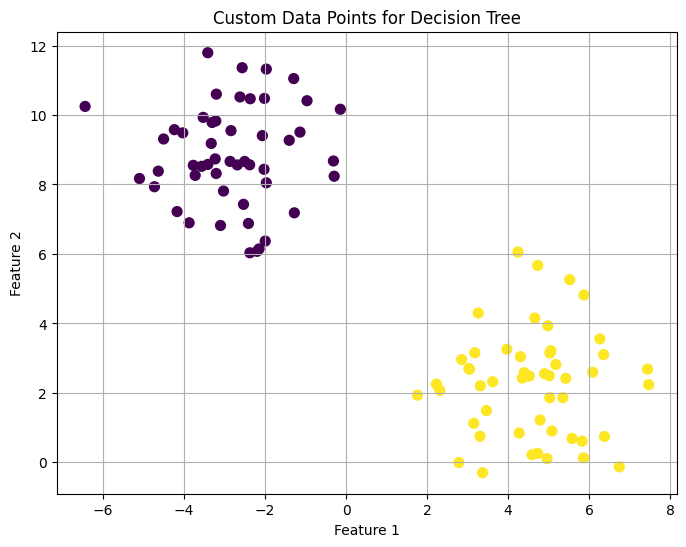

In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

# Generate custom data points
X_dt, y_dt = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.5)

# Plot the generated data
plt.figure(figsize=(8, 6))
plt.scatter(X_dt[:, 0], X_dt[:, 1], c=y_dt, cmap='viridis', s=50)
plt.title('Custom Data Points for Decision Tree')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

Now, let's implement a `DecisionTreeClassifier` and visualize its decision boundaries. Decision trees naturally create axis-parallel splits.

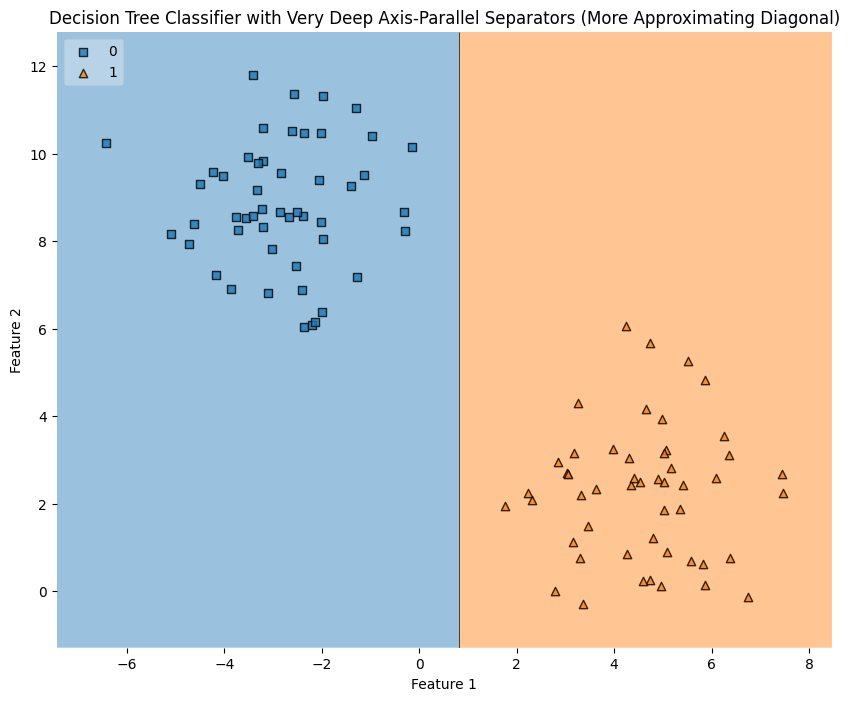

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from mlxtend.plotting import plot_decision_regions

# Train a Decision Tree Classifier with an even higher max_depth
dt_classifier_deep = DecisionTreeClassifier(random_state=42, max_depth=10) # Increased depth to 10
dt_classifier_deep.fit(X_dt, y_dt)

# Plot the decision regions
plt.figure(figsize=(10, 8))
plot_decision_regions(X_dt, y_dt, clf=dt_classifier_deep, legend=2)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Tree Classifier with Very Deep Axis-Parallel Separators (More Approximating Diagonal)')
plt.show()